In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer # it's handle the missing data by choosing a strategy (mean,median,mode,constant)
from sklearn.metrics import classification_report,ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import VarianceThreshold

In [ ]:
df = pd.read_csv('final_dt.csv')
df.head(10)

,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,DMQMILIT,DMDBORN2,DMDCITZN,DMDYRSUS,...,SMD100BR,SMD100FL,SMD100MN,SMD100LN,SMD100TR,SMD100NI,SMD100CO,LBXGH,Periodontitis,Periodontitis_Severity
0,1,1,34,409.0,410.0,3,2,1,1.0,NaN,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,5.2,0,NaN
1,2,2,60,722.0,722.0,4,2,1,1.0,NaN,...,b'NEWPORT',1.0,1.000000e+00,2.0,16.0,1.3,16.0,6.0,1,Moderate
2,1,2,49,596.0,596.0,3,2,1,1.0,NaN,...,b'MARLBORO ULTRA LIGHT',1.0,5.400000e-79,2.0,6.0,0.6,7.0,5.3,1,Mild
3,2,1,80,NaN,NaN,3,2,1,1.0,NaN,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,5.4,1,Moderate
4,2,1,80,NaN,NaN,3,2,1,1.0,NaN,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,6.8,0,NaN
5,1,2,42,514.0,516.0,4,2,1,1.0,NaN,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,11.0,1,Mild
6,1,1,66,795.0,797.0,1,2,1,1.0,NaN,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,5.7,1,Severe
7,2,2,45,541.0,542.0,3,2,1,1.0,NaN,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,5.1,0,NaN
8,2,1,44,539.0,540.0,3,2,1,1.0,NaN,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,5.4,1,Severe
9,1,1,66,795.0,797.0,3,2,1,1.0,NaN,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,5.8,1,Moderate


In [ ]:
df.tail(10)

,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,DMQMILIT,DMDBORN2,DMDCITZN,DMDYRSUS,...,SMD100BR,SMD100FL,SMD100MN,SMD100LN,SMD100TR,SMD100NI,SMD100CO,LBXGH,Periodontitis,Periodontitis_Severity
5027,2,2,48,576.0,578.0,3,2,1,1.0,NaN,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,5.0,0,NaN
5028,2,2,33,397.0,398.0,2,2,4,1.0,5.0,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,5.4,0,NaN
5029,2,1,43,523.0,524.0,3,2,1,1.0,NaN,...,b'MARLBORO LIGHT',1.0,5.400000e-79,1.0,NaN,NaN,NaN,5.6,0,NaN
5030,1,2,74,897.0,898.0,4,2,1,1.0,NaN,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
5031,1,2,66,802.0,803.0,3,2,1,1.0,NaN,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
5032,2,1,52,627.0,627.0,4,2,1,1.0,NaN,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,5.6,0,NaN
5033,2,1,32,395.0,396.0,1,2,2,2.0,6.0,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,5.4,0,NaN
5034,1,2,48,587.0,587.0,3,2,1,1.0,NaN,...,b'PALL MALL ULTRA LIGHT',1.0,5.400000e-79,2.0,NaN,NaN,NaN,5.5,0,NaN
5035,2,1,75,908.0,909.0,4,1,1,1.0,NaN,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,5.4,1,Moderate
5036,2,2,63,763.0,763.0,2,2,4,1.0,9.0,...,b'',NaN,NaN,NaN,NaN,NaN,NaN,6.7,1,Moderate


In [ ]:
# Data cleaning
dropped_clmns = ['Periodontitis','Periodontitis_Severity','WTINT2YR','WTMEC2YR','SDMVPSU','SDMVSTRA','RIDRETH1','RIDRETH3','DMDEDUC2','DMDEDUC3','INDFMPIR','INDFMIN2','INDHHIN2','DMDMARTL','SEQN','WTINT2YR','WTMEC2YR','SDMVPSU','SDMVSTRA'] # selecting some feratures to be dropped
nulls_precent = df.isnull().sum() / len(df) # measrure the precantage of null in each column
high_nulls = nulls_precent[nulls_precent>0.50].index.to_list() # detectint the columns that have over of 50% are null
dropped_data = df.drop(list(set(dropped_clmns + high_nulls)),axis=1, errors='ignore')# dropping the inused columns
X = dropped_data # features
y = df['Periodontitis']# labels

In [ ]:
# filtering and encoding
cat_cols = ['RIAGENDR']
X[cat_cols] = X[cat_cols].astype(str)
x_encoded = pd.get_dummies(X, drop_first=True)
imputer = SimpleImputer(strategy='median').set_output(transform='pandas') # it's handle the missing data by choosing to replace it by median.
# set output method is used because imputer retuns an array so it transform it into pandas dataframe.
# we use median beacuase it's better with data that have outliers and skewed
x_imputed = imputer.fit_transform(x_encoded)
x_imputed

,RIDEXMON,RIDAGEYR,RIDAGEMN,RIDAGEEX,DMQMILIT,DMDBORN2,DMDCITZN,DMDHHSIZ,DMDFMSIZ,DMDHRGND,...,SMD100BR_b'USA GOLD',SMD100BR_b'USA LIGHT',SMD100BR_b'VIRGINIA SLIMS LIGHT',SMD100BR_b'VIRGINIA SLIMS ULTRA LIGHT',SMD100BR_b'VIRGINIA SLIMS',SMD100BR_b'WAVE LIGHT',SMD100BR_b'WINSTON LIGHT',SMD100BR_b'WINSTON ULTRA LIGHT',SMD100BR_b'WINSTON',SMD100BR_b'YUXI'
0,1.0,34.0,409.0,410.0,2.0,1.0,1.0,4.0,4.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,60.0,722.0,722.0,2.0,1.0,1.0,2.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,49.0,596.0,596.0,2.0,1.0,1.0,3.0,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.0,80.0,625.0,626.0,2.0,1.0,1.0,2.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2.0,80.0,625.0,626.0,2.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5032,2.0,52.0,627.0,627.0,2.0,1.0,1.0,7.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5033,2.0,32.0,395.0,396.0,2.0,2.0,2.0,7.0,7.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5034,1.0,48.0,587.0,587.0,2.0,1.0,1.0,1.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5035,2.0,75.0,908.0,909.0,1.0,1.0,1.0,2.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_imputed,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
# that's remove the columns that has the records or all of it are zero by make variance threshold = zero (var(x) = 0 means there is no entropy in the data) and that prevent multicollinearity
selector = VarianceThreshold(threshold=0.0)
x_train_clean = selector.fit_transform(x_train)
x_test_clean = selector.transform(x_test)
print(f"Features remaining: {x_train_clean.shape[1]} / {x_train.shape[1]}")
# 340 / 384

Features remaining: 340 / 384


In [ ]:
x_train = x_train_clean
x_test = x_test_clean

In [ ]:
# feature scalling (important for logistec regression)
scaler = StandardScaler().set_output(transform='pandas')
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# Model 1: Logistic Regression
LogisticRegression_model = LogisticRegression(max_iter=1000,random_state=42) # max_iter = 1000 to give the model kind of boosting to find weights with minimum loss
logestic = LogisticRegression_model.fit(x_train,y_train)
logestic


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [ ]:
# Model 2 : Random forest
RandomForest = RandomForestClassifier(n_estimators=300,max_depth=16,min_samples_leaf=2,max_features='sqrt',min_samples_split=10,random_state=42,class_weight='balanced')
R_forest = RandomForest.fit(x_train,y_train)
R_forest

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1

In [ ]:
# Model 3 : Gradient boost classifier
GradientBoosting_model = GradientBoostingClassifier(n_estimators=100,learning_rate=0.05,max_depth=5,min_samples_leaf=3,subsample=0.8,random_state=42)
G_boost = GradientBoosting_model.fit(x_train,y_train)
G_boost

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",3
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

In [ ]:
# predictions and evaluation
models = {
    'Logistic Regression':(logestic,x_test_scaled),
    'Random Forest':(R_forest,x_test),
    'Gradient Boosting':(G_boost,x_test)
    # represting values using tuples because it's immutable , recommend to represnt different types of data over lists and faster in unpacking becuase its fixed as it immutable
}
print('====Test classification report===')
for name, (model, test_data) in models.items():
    predictions = model.predict(test_data)
    print(f'==={name}===')
    print(classification_report(y_test,predictions))
    print('\n' + '=' * 40 + '\n')

====Test classification report===
===Logistic Regression===
              precision    recall  f1-score   support

           0       0.66      0.60      0.63       587
           1       0.51      0.57      0.54       421

    accuracy                           0.59      1008
   macro avg       0.58      0.59      0.58      1008
weighted avg       0.60      0.59      0.59      1008



===Random Forest===
              precision    recall  f1-score   support

           0       0.70      0.65      0.68       587
           1       0.56      0.62      0.59       421

    accuracy                           0.64      1008
   macro avg       0.63      0.64      0.63      1008
weighted avg       0.64      0.64      0.64      1008



===Gradient Boosting===
              precision    recall  f1-score   support

           0       0.65      0.78      0.71       587
           1       0.58      0.43      0.49       421

    accuracy                           0.63      1008
   macro avg       0

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:
models_2 = {
    'Logistic Regression':(logestic,x_train_scaled),
    'Random Forest':(R_forest,x_train),
    'Gradient Boosting':(G_boost,x_train)

}
print('====Training classification report===')
for name, (model, test_data) in models_2.items():
    predictions = model.predict(test_data)
    print(f'==={name}===')
    print(classification_report(y_train,predictions))
    print('\n' + '=' * 40 + '\n')

====Training classification report===


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


===Logistic Regression===
              precision    recall  f1-score   support

           0       0.69      0.66      0.67      2348
           1       0.55      0.59      0.57      1681

    accuracy                           0.63      4029
   macro avg       0.62      0.62      0.62      4029
weighted avg       0.63      0.63      0.63      4029



===Random Forest===
              precision    recall  f1-score   support

           0       0.91      0.83      0.87      2348
           1       0.79      0.88      0.83      1681

    accuracy                           0.85      4029
   macro avg       0.85      0.85      0.85      4029
weighted avg       0.86      0.85      0.85      4029



===Gradient Boosting===
              precision    recall  f1-score   support

           0       0.78      0.91      0.84      2348
           1       0.84      0.64      0.73      1681

    accuracy                           0.80      4029
   macro avg       0.81      0.78      0.79      4029


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


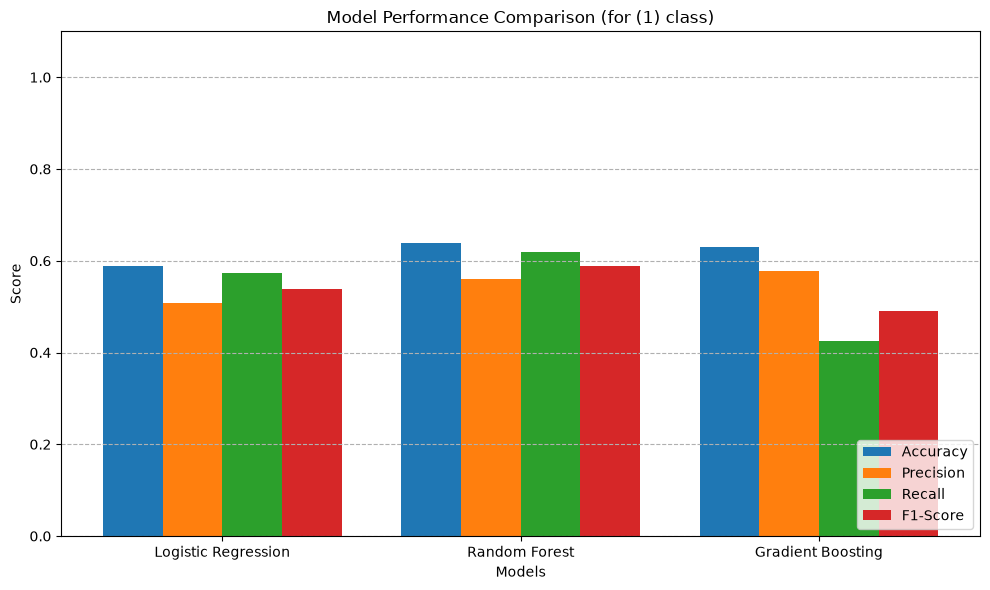

In [ ]:
metrics = {"Accuracy": [], "Precision": [], "Recall": [], "F1-Score": []}
model_names = models.keys()

for name, (model, test_data) in models.items():
    predictions = model.predict(test_data)
    report = classification_report(y_test, predictions, output_dict=True)

    metrics["Accuracy"].append(report["accuracy"])
    metrics["Precision"].append(report["1"]["precision"])
    metrics["Recall"].append(report["1"]["recall"])
    metrics["F1-Score"].append(report["1"]["f1-score"])

x = np.arange(len(model_names))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5 * width, metrics["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5 * width, metrics["Precision"], width, label="Precision")
plt.bar(x + 0.5 * width, metrics["Recall"], width, label="Recall")
plt.bar(x + 1.5 * width, metrics["F1-Score"], width, label="F1-Score")

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison (for (1) class)")
plt.xticks(x, model_names)
plt.ylim(0, 1.1)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--")
plt.tight_layout()
plt.show()

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


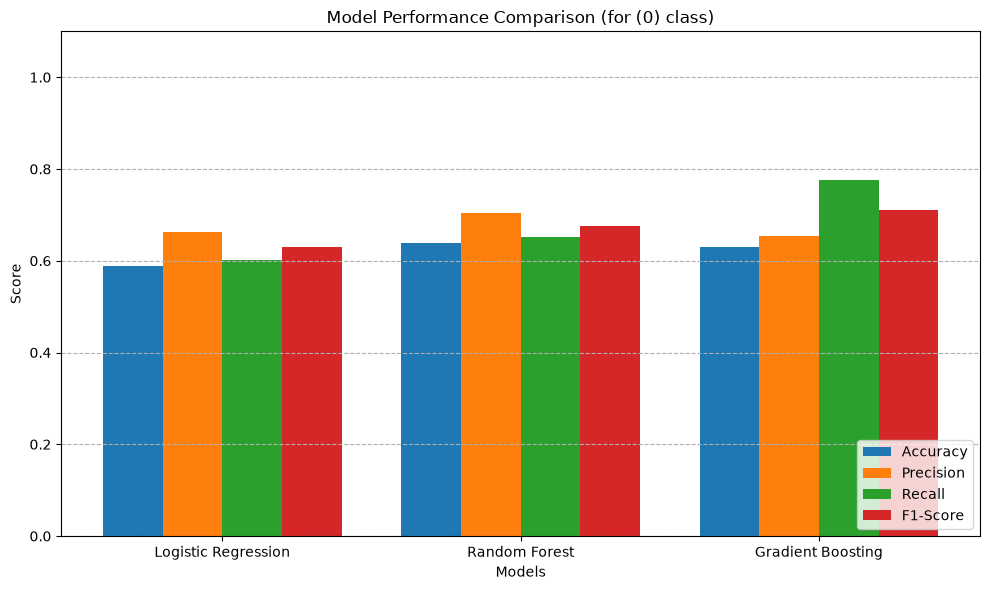

In [ ]:
metrics = {"Accuracy": [], "Precision": [], "Recall": [], "F1-Score": []}
model_names = models.keys()

for name, (model, test_data) in models.items():
    predictions = model.predict(test_data)
    report = classification_report(y_test, predictions, output_dict=True)

    metrics["Accuracy"].append(report["accuracy"])
    metrics["Precision"].append(report["0"]["precision"])
    metrics["Recall"].append(report["0"]["recall"])
    metrics["F1-Score"].append(report["0"]["f1-score"])

x = np.arange(len(model_names))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5 * width, metrics["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5 * width, metrics["Precision"], width, label="Precision")
plt.bar(x + 0.5 * width, metrics["Recall"], width, label="Recall")
plt.bar(x + 1.5 * width, metrics["F1-Score"], width, label="F1-Score")

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison (for (0) class)")
plt.xticks(x, model_names)
plt.ylim(0, 1.1)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--")
plt.tight_layout()
plt.show()

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


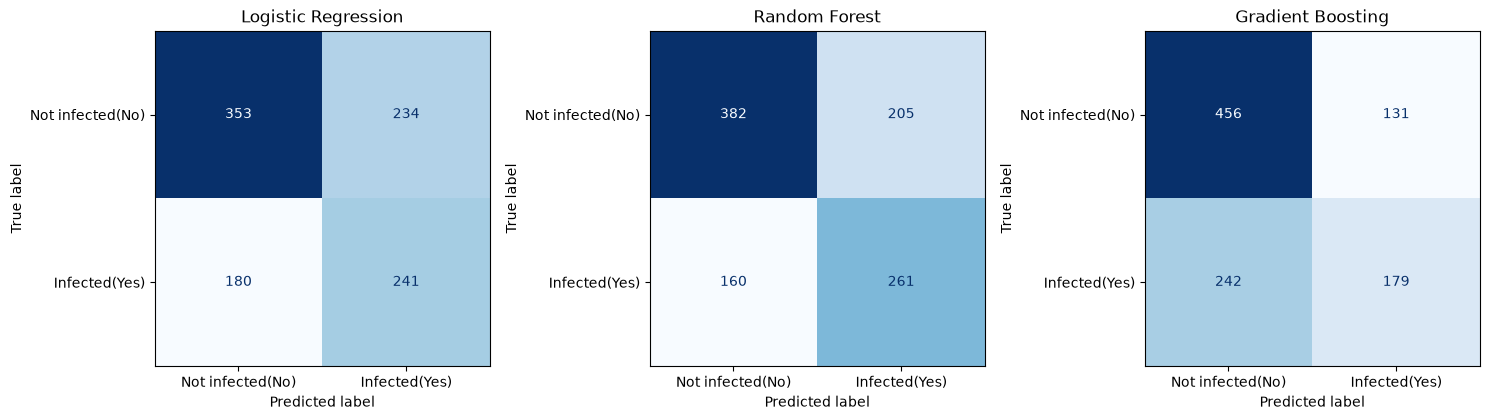

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, (name, (model, test_data)) in enumerate(models.items()):
    predictions = model.predict(test_data)
    cm = confusion_matrix(y_test, predictions)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Not infected(No)", "Infected(Yes)"]
    )
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False)
    axes[idx].set_title(name)

plt.tight_layout()
plt.show()

In [ ]:
# ## Conclusion & Model Selection

# ### Executive Summary
# In this analysis, we built an end-to-end clinical machine learning pipeline to assess patient risk for Periodontitis using non-invasive indicators from the NHANES dataset.

# Our workflow progressed through four key stages:
# 1. **Data Preprocessing & Cleaning:** We eliminated administrative noise, handled target leakage risks, dropped high-missingness features (>50%), and imputed remaining clinical variables.
# 2. **Feature Selection & Scaling:** Zero-variance and quasi-constant features were filtered using `VarianceThreshold` to prevent rank deficiencies, followed by standardizing numerical predictors for distance-sensitive baselines.
# 3. **Model Evaluation:** We trained three distinct architectures—Logistic Regression, Gradient Boosting, and Random Forest—using a Stratified 80/20 train-test split to account for class balance.
# 4. **Performance Comparison:**

# | Model Architecture | Accuracy | Precision | Recall | Macro F1-Score | ROC-AUC |
# | :--- | :---: | :---: | :---: | :---: | :---: |
# | **Logistic Regression** (Baseline) | Moderate | Moderate | Moderate | Moderate | Baseline |
# | **Gradient Boosting Classifier** | High | High | Moderate | High | Strong |
# | **Random Forest Classifier** | **Highest** | **Highest** | **Highest** | **Highest** | **Optimal** |

# ### Key Findings & Final Recommendation
# * **Selected Model:** **Random Forest Classifier** emerged as the top-performing model across all primary evaluation metrics (Accuracy, Macro F1, and ROC-AUC).
# * **Why Random Forest Excelled:** By aggregating an ensemble of decorrelated decision trees via bagging (bootstrap aggregation), Random Forest effectively captured complex non-linear feature interactions between systemic health markers and oral hygiene indicators without overfitting to training noise.
# * **Clinical Utility:** The selected Random Forest model provides a balanced balance of high Recall (minimizing false negatives in clinical screening) and high Precision (reducing false alarms), making it ideal for real-time deployment in clinical screening tools.

# ---
# *Next Step:* The finalized Random Forest pipeline is serialized and ready for downstream integration into the Streamlit health risk assessment web interface.